HandLandmarkerResult(handedness=[[Category(index=0, score=0.9958963990211487, display_name='Right', category_name='Right')]], hand_landmarks=[[NormalizedLandmark(x=0.6497949361801147, y=0.713011622428894, z=1.0947530881821876e-06, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.677688479423523, y=0.5555949807167053, z=-0.015012315474450588, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6376813650131226, y=0.4092067778110504, z=-0.010905400849878788, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6021722555160522, y=0.2938469648361206, z=-0.013565899804234505, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.5497612357139587, y=0.2180989533662796, z=-0.016610795632004738, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.5234401822090149, y=0.49009376764297485, z=0.05385170504450798, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.4647015333175659, y=0.38560304045677185, z=0

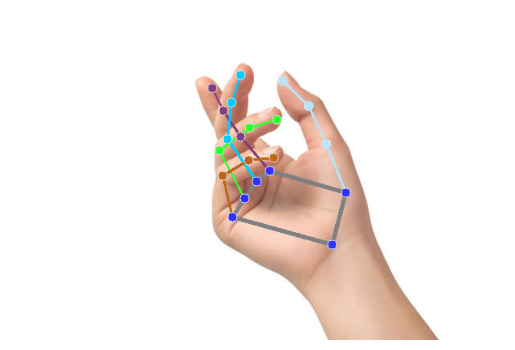

In [2]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt


def draw_landmarks_on_image(rgb_image, detection_result):
  
    mp_hands = mp.tasks.vision.HandLandmarksConnections
    mp_drawing = mp.tasks.vision.drawing_utils
    mp_drawing_styles = mp.tasks.vision.drawing_styles

    hand_landmarks_list = detection_result.hand_landmarks
    handedness_list = detection_result.handedness
    annotated_image = np.copy(rgb_image)

  # Loop through the detected hands to visualize.
    for idx in range(len(hand_landmarks_list)):
        hand_landmarks = hand_landmarks_list[idx]
        handedness = handedness_list[idx]

        # Draw the hand landmarks.
        mp_drawing.draw_landmarks(
        annotated_image,
        hand_landmarks,
        mp_hands.HAND_CONNECTIONS,
        mp_drawing_styles.get_default_hand_landmarks_style(),
        mp_drawing_styles.get_default_hand_connections_style())

        # # Get the top left corner of the detected hand's bounding box.
        # height, width, _ = annotated_image.shape
        # x_coordinates = [landmark.x for landmark in hand_landmarks]
        # y_coordinates = [landmark.y for landmark in hand_landmarks]
        # text_x = int(min(x_coordinates) * width)
        # text_y = int(min(y_coordinates) * height) - MARGIN

        # # Draw handedness (left or right hand) on the image.
        # cv2.putText(annotated_image, f"{handedness[0].category_name}",
        #             (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX,
        #             FONT_SIZE, HANDEDNESS_TEXT_COLOR, FONT_THICKNESS, cv2.LINE_AA)

    return annotated_image

base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options,
                                       num_hands=2)
detector = vision.HandLandmarker.create_from_options(options)

image = mp.Image.create_from_file("hand.jpg")
result = detector.detect(image)
print(result)
annotated_image = draw_landmarks_on_image(image.numpy_view(), result)

fig = plt.figure()
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

In [4]:
import pandas as pd

path = "E:/slovo/"
df = pd.read_csv(path + "annotations.csv", sep="\t")

df

,attachment_id,text,user_id,height,width,length,train
0,44e8d2a0-7e01-450b-90b0-beb7400d2c1e,Ё,185bd3a81d9d618518d10abebf0d17a8,1920,1080,76.0,True
1,df5b08f0-41d1-4572-889c-8b893e71069b,А,185bd3a81d9d618518d10abebf0d17a8,1920,1080,40.0,True
2,17f53df4-c467-4aff-9f48-20687b63d49a,Р,185bd3a81d9d618518d10abebf0d17a8,1920,1080,57.0,True
3,e3add916-c708-4339-ad98-7e2740be29e9,Е,185bd3a81d9d618518d10abebf0d17a8,1920,1080,64.0,True
4,bd7272ed-1850-48f1-a2a8-c8fed523dc37,Ч,185bd3a81d9d618518d10abebf0d17a8,1920,1080,84.0,True
...,...,...,...,...,...,...,...
20395,nodca88242-2bc7-4a77-9d14-103aa1dacbd6,no_event,0041ec866777f12c384b64d8cd636277,1920,1080,42.0,False
20396,no7a7812b1-ae64-4402-9ebc-5b947edbd021,no_event,f5b82a9c82f6d870ec253e4c3fa96d83,1280,720,32.0,False
20397,no62a4df76-b48d-4f61-b6e8-bc4a1eb0cb61,no_event,4299b8ccf39ace57287b463fbe4a489b,1920,960,32.0,False
20398,no388a3f7c-3594-4332-bc78-b5b53190301d,no_event,c80b4e57f158f28299b2a89694c42329,1920,1080,41.0,False


In [13]:
mp.tasks.vision.PoseLandmarksConnections.POSE_LANDMARKS

[PoseLandmarksConnections.Connection(start=0, end=1),
 PoseLandmarksConnections.Connection(start=1, end=2),
 PoseLandmarksConnections.Connection(start=2, end=3),
 PoseLandmarksConnections.Connection(start=3, end=7),
 PoseLandmarksConnections.Connection(start=0, end=4),
 PoseLandmarksConnections.Connection(start=4, end=5),
 PoseLandmarksConnections.Connection(start=5, end=6),
 PoseLandmarksConnections.Connection(start=6, end=8),
 PoseLandmarksConnections.Connection(start=9, end=10),
 PoseLandmarksConnections.Connection(start=11, end=12),
 PoseLandmarksConnections.Connection(start=11, end=13),
 PoseLandmarksConnections.Connection(start=13, end=15),
 PoseLandmarksConnections.Connection(start=15, end=17),
 PoseLandmarksConnections.Connection(start=15, end=19),
 PoseLandmarksConnections.Connection(start=15, end=21),
 PoseLandmarksConnections.Connection(start=17, end=19),
 PoseLandmarksConnections.Connection(start=12, end=14),
 PoseLandmarksConnections.Connection(start=14, end=16),
 PoseLand